# 箱线图

/tmp/ipykernel_3291862/2421639668.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='kcat', data=df_plot, ax=axes[0], palette=palette, showfliers=True)
/tmp/ipykernel_3291862/2421639668.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Km', data=df_plot, ax=axes[1], palette=palette, showfliers=True)


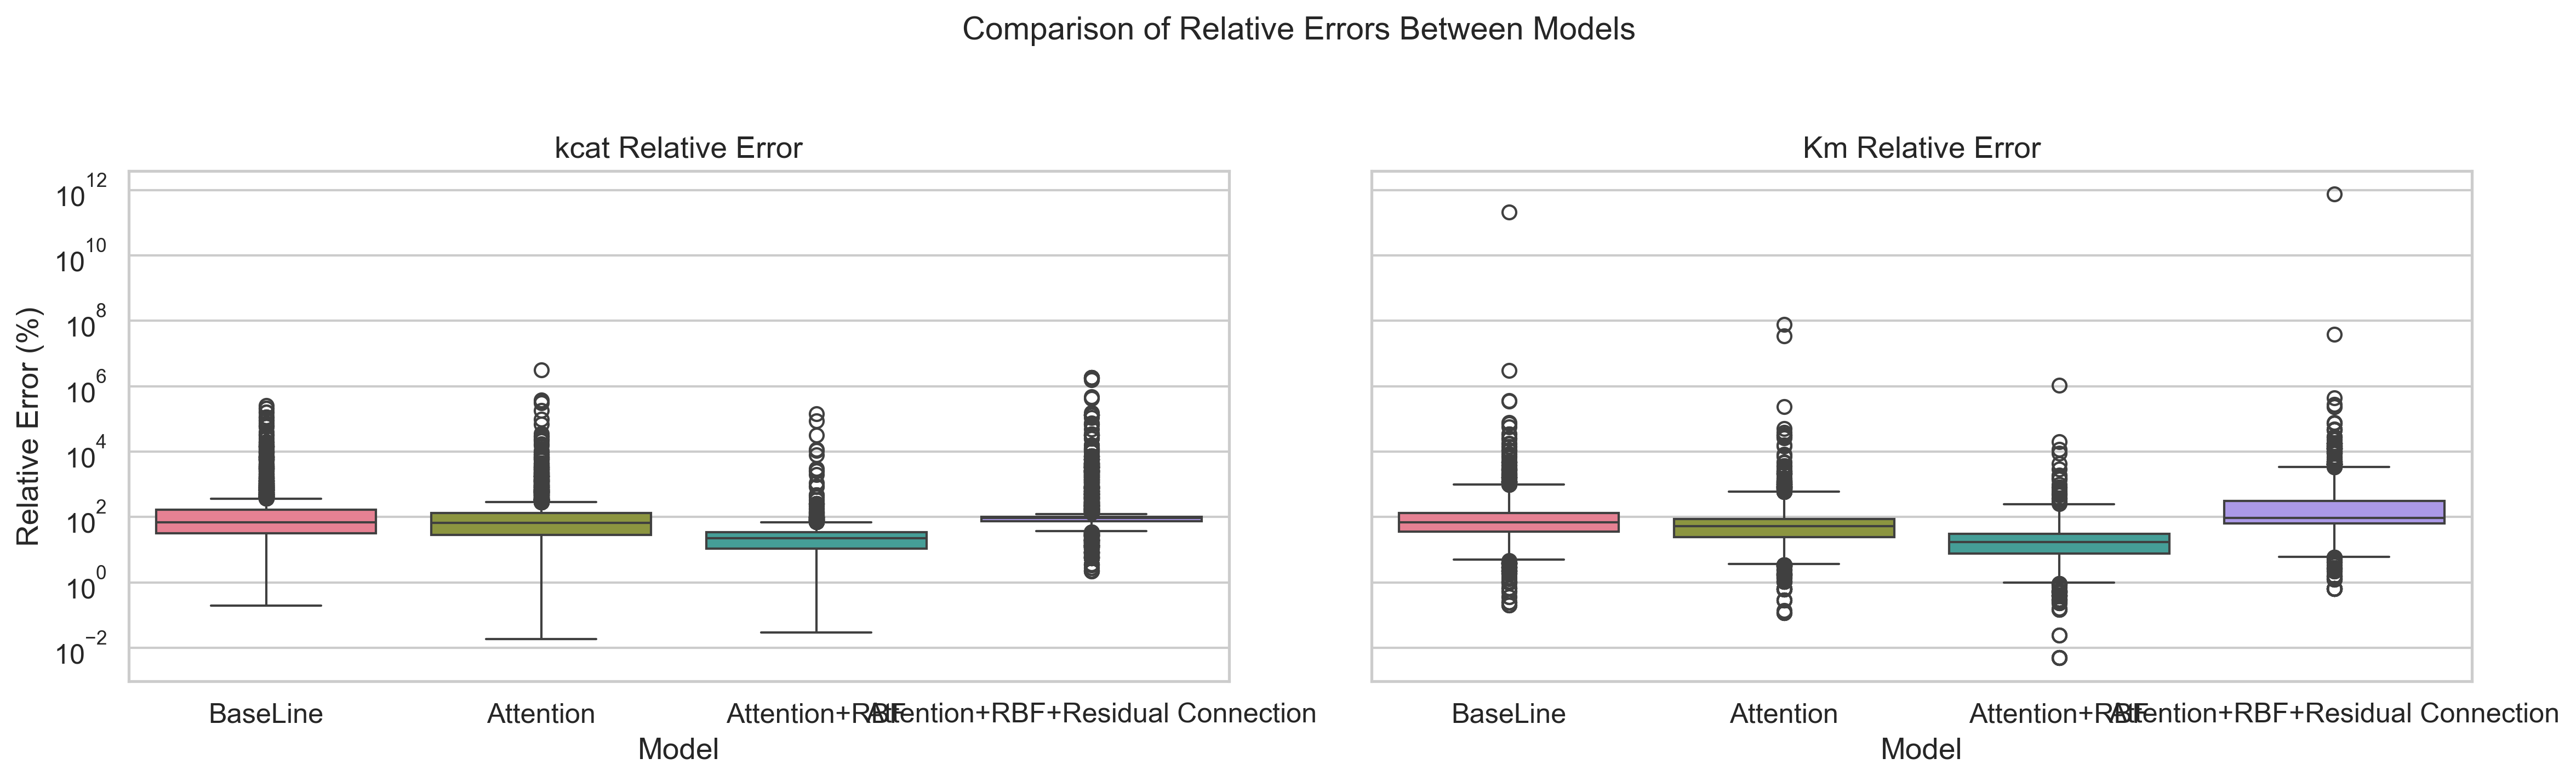

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 示例路径（请根据实际情况替换）
csv_paths = [
    '/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr/val_pred_results.csv',
    '/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr_attention/val_pred_results.csv',

    '/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr_attention_rbf/val_pred_results.csv',
         '/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr_attention_rbf_residual/val_pred_results.csv',
    
]

# 模型名称（请根据需要替换）
model_names = ['PGNN-Basic',  'PGNN-Att', 'PGNN-Full', 'PGNN-Res'] 

# 加载数据并提取误差
kcat_errors = []
km_errors = []
models = []

for i, csv_path in enumerate(csv_paths):
    df = pd.read_csv(csv_path)
    kcat_errors.append(df['kcat_error'] * 100)  # 转为百分比
    km_errors.append(df['km_error'] * 100)
    models.extend([model_names[i]] * len(df))

# 构建DataFrame用于绘图
df_plot = pd.DataFrame({
    'kcat': pd.concat(kcat_errors, ignore_index=True),
    'Km': pd.concat(km_errors, ignore_index=True),
    'Model': models
})

# 颜色设置（为四个模型选择颜色）
# palette = ['#AFCBE3', '#B9E3C6', '#F4C2C2', '#D3D3D3',"#E2F59E"]  # 浅蓝、浅绿、浅红、灰色

# # 画图
# sns.set(style='whitegrid', font_scale=1.1)
sns.set(style='whitegrid', font_scale=1.1)
# 使用Seaborn的'husl'调色板，自动生成适合模型数量的颜色
palette = sns.color_palette("husl", n_colors=len(df_plot['Model'].unique()))
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# kcat误差箱线图
sns.boxplot(y='kcat', data=df_plot, ax=axes[0], palette=palette, showfliers=True)
axes[0].set_yscale('log')
axes[0].set_title('kcat Relative Error')
axes[0].set_ylabel('Relative Error (%)')

# Km误差箱线图
sns.boxplot(=y='Km', data=df_plot, ax=axes[1], palette=palette, showfliers=True)
axes[1].set_yscale('log')
axes[1].set_title('Km Relative Error')
axes[1].set_ylabel('')

# 总标题
plt.suptitle('Comparison of Relative Errors Between Models', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_3291862/4054655262.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='kcat', data=df_plot, ax=axes[0], palette=palette, showfliers=True)
/tmp/ipykernel_3291862/4054655262.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Km', data=df_plot, ax=axes[1], palette=palette, showfliers=True)


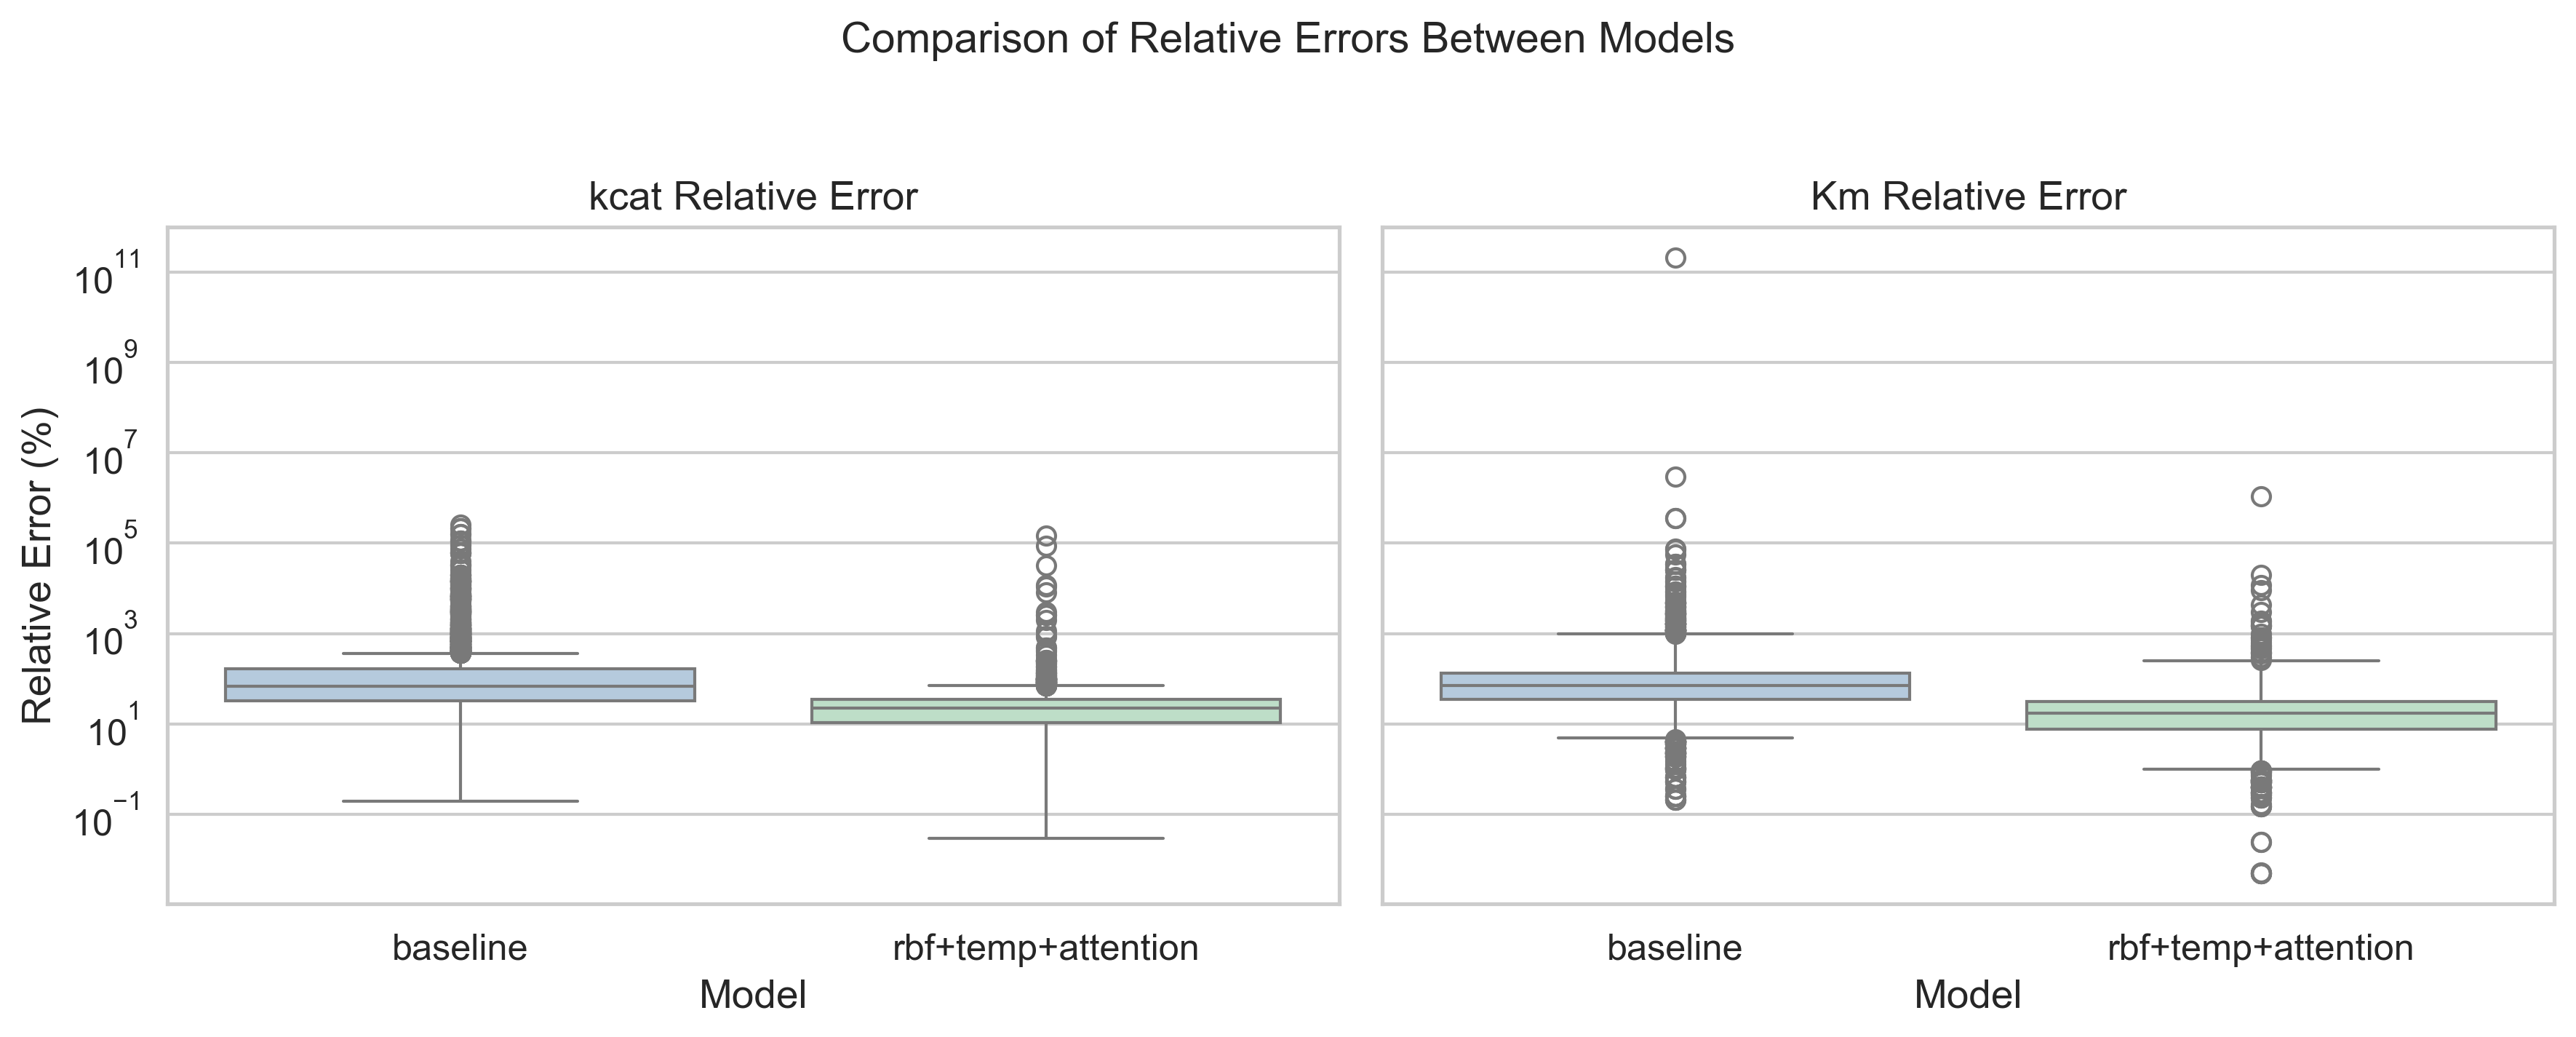

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 示例路径（请根据实际情况替换）
csv_path1 = '/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr/val_pred_results.csv'
csv_path2 = '/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr_attention_rbf/val_pred_results.csv'

# 加载数据
df1 = pd.read_csv(csv_path1)
df2 = pd.read_csv(csv_path2)

# 提取并转为百分比误差
kcat1 = df1['kcat_error'] * 100
kcat2 = df2['kcat_error'] * 100
km1 = df1['km_error'] * 100
km2 = df2['km_error'] * 100

# 构建DataFrame用于绘图
df_plot = pd.DataFrame({
    'kcat': pd.concat([kcat1, kcat2], ignore_index=True),
    'Km': pd.concat([km1, km2], ignore_index=True),
    'Model': ['baseline'] * len(kcat1) + ['rbf+temp+attention'] * len(kcat2)
})

# 颜色设置
palette = ['#AFCBE3', '#B9E3C6']  # 浅蓝 + 浅绿

# 画图
sns.set(style='whitegrid', font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# kcat误差箱线图
sns.boxplot(x='Model', y='kcat', data=df_plot, ax=axes[0], palette=palette, showfliers=True)
axes[0].set_yscale('log')
axes[0].set_title('kcat Relative Error')
axes[0].set_ylabel('Relative Error (%)')

# Km误差箱线图
sns.boxplot(x='Model', y='Km', data=df_plot, ax=axes[1], palette=palette, showfliers=True)
axes[1].set_yscale('log')
axes[1].set_title('Km Relative Error')
axes[1].set_ylabel('')

# 总标题
plt.suptitle('Comparison of Relative Errors Between Models', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [2]:
import pandas as pd
data_dir1="/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr/val_pred_results.csv"
data_dir2="/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/nopqr/val_pred_results.csv"
df = pd.read_csv(data_dir)# 预测成功为1，失败为0
df['kcat_success'] = (df['kcat_error'] < 0.5).astype(int)
df['km_success'] = (df['km_error'] < 0.5).astype(int)
print('kcat预测成功率:', df['kcat_success'].mean())
print('km预测成功率:', df['km_success'].mean())
df['both_success'] = ((df['kcat_success'] == 1) & (df['km_success'] == 1)).astype(int)
print('两者都成功的比例:', df['both_success'].mean())
import matplotlib.pyplot as plt

labels = ['kcat', 'km', 'both']
success_rates = [
    df['kcat_success'].mean(),
    df['km_success'].mean(),
    df['both_success'].mean()
]

plt.bar(labels, success_rates)
plt.ylabel('Success Rate')
plt.title('Prediction Success Rate (<50% error)')
plt.ylim(0, 1)
plt.show()
plt.figure(figsize=(6,6))
plt.scatter(df['kcat_error'], df['km_error'], 
            c=df['both_success'], cmap='bwr', alpha=0.5)
plt.axvline(0.5, color='grey', linestyle='--')
plt.axhline(0.5, color='grey', linestyle='--')
plt.xlabel('kcat_error')
plt.ylabel('km_error')
plt.title('Scatter of Errors (Red=Success, Blue=Fail)')

# 设置坐标轴范围，只显示0~2区间（可根据实际分布调整）
plt.xlim(0, 2000)
plt.ylim(0, 2000)

plt.show()
import seaborn as sns

confusion = pd.crosstab(df['kcat_success'], df['km_success'])
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('km_success')
plt.ylabel('kcat_success')
plt.title('Success/Fail Confusion Matrix')
plt.show()

NameError: name 'data_dir' is not defined

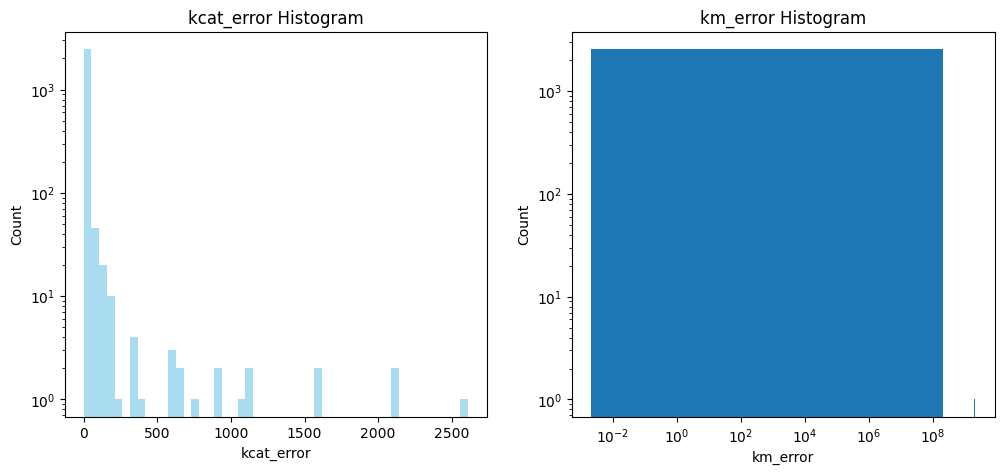

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['kcat_error'], bins=50, color='skyblue', alpha=0.7)
plt.xlabel('kcat_error')
plt.ylabel('Count')
plt.title('kcat_error Histogram')
plt.yscale('log')

plt.subplot(1,2,2)
plt.hist(df['km_error'])
plt.xlabel('km_error')
plt.ylabel('Count')
plt.title('km_error Histogram')
plt.xscale('log')
plt.yscale('log')
# plt.tight_layout()
plt.show()

/tmp/ipykernel_2376646/1602572826.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['kcat_error'], df['km_error']], labels=['kcat_error', 'km_error'], showfliers=True)


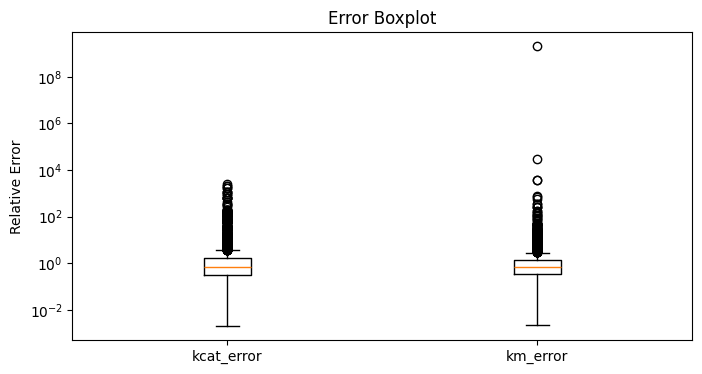

In [10]:
plt.figure(figsize=(8,4))
plt.boxplot([df['kcat_error'], df['km_error']], labels=['kcat_error', 'km_error'], showfliers=True)
plt.ylabel('Relative Error')
plt.title('Error Boxplot')
plt.yscale('log')
plt.show()

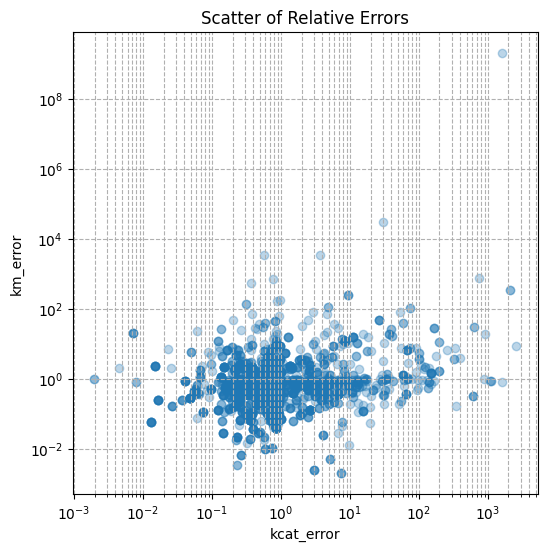

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(df['kcat_error'], df['km_error'], alpha=0.3)
plt.xlabel('kcat_error')
plt.ylabel('km_error')
plt.title('Scatter of Relative Errors')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.show()

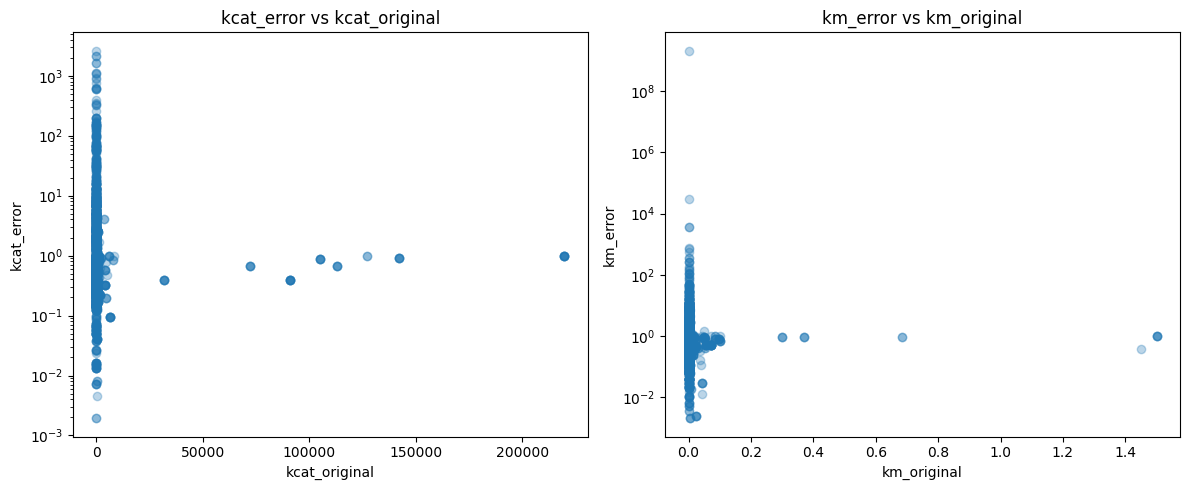

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(df['kcat_original'], df['kcat_error'], alpha=0.3)
plt.xlabel('kcat_original')
plt.ylabel('kcat_error')
plt.yscale('log')
plt.title('kcat_error vs kcat_original')

plt.subplot(1,2,2)
plt.scatter(df['km_original'], df['km_error'], alpha=0.3)
plt.xlabel('km_original')
plt.ylabel('km_error')
plt.yscale('log')
plt.title('km_error vs km_original')
plt.tight_layout()
plt.show()

In [14]:
print('kcat_error分位数:', df['kcat_error'].quantile([0.25,0.5,0.75,0.9,0.95,0.99]))
print('km_error分位数:', df['km_error'].quantile([0.25,0.5,0.75,0.9,0.95,0.99]))

kcat_error分位数: 0.25      0.320007
0.50      0.693636
0.75      1.666474
0.90      7.898699
0.95     29.747406
0.99    195.497788
Name: kcat_error, dtype: float64
km_error分位数: 0.25     0.354383
0.50     0.700927
0.75     1.337161
0.90     3.738809
0.95     9.509191
0.99    49.809152
Name: km_error, dtype: float64


/tmp/ipykernel_2376646/2420911089.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kcat_err_pct, km_err_pct], labels=['kcat_error(%)', 'km_error(%)'], showfliers=True)


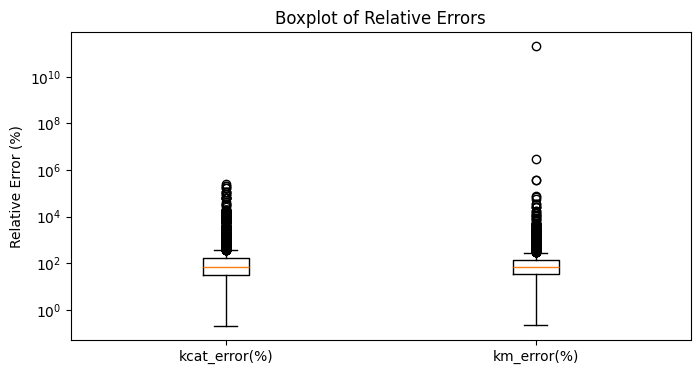

kcat_error离群点index: [6, 12, 14, 19, 33, 37, 44, 46, 54, 66, 72, 78, 102, 107, 113, 115, 119, 126, 129, 134, 135, 138, 154, 158, 160, 161, 167, 169, 178, 180, 181, 187, 190, 206, 212, 229, 233, 249, 255, 256, 257, 267, 268, 271, 276, 282, 297, 307, 311, 339, 340, 342, 351, 353, 357, 364, 367, 379, 380, 388, 390, 400, 410, 411, 412, 418, 431, 434, 448, 452, 457, 459, 467, 471, 483, 506, 507, 509, 510, 513, 521, 523, 526, 527, 528, 536, 539, 543, 559, 568, 574, 589, 605, 606, 614, 633, 635, 636, 639, 658, 662, 666, 669, 674, 679, 680, 688, 693, 699, 717, 720, 728, 730, 731, 737, 740, 774, 779, 782, 788, 791, 792, 801, 807, 820, 821, 824, 826, 828, 829, 833, 835, 846, 848, 851, 859, 868, 870, 871, 885, 886, 889, 894, 896, 903, 913, 920, 923, 924, 927, 929, 937, 938, 946, 950, 956, 959, 960, 971, 978, 979, 981, 982, 989, 993, 999, 1000, 1001, 1004, 1005, 1006, 1008, 1009, 1012, 1015, 1028, 1033, 1037, 1046, 1049, 1052, 1056, 1065, 1073, 1075, 1085, 1088, 1092, 1099, 1109, 1112, 1115, 1124, 

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# 百分制
kcat_err_pct = df['kcat_error'] * 100
km_err_pct = df['km_error'] * 100

# 箱线图
plt.figure(figsize=(8,4))
plt.boxplot([kcat_err_pct, km_err_pct], labels=['kcat_error(%)', 'km_error(%)'], showfliers=True)
plt.ylabel('Relative Error (%)')
plt.title('Boxplot of Relative Errors')
plt.yscale('log')
plt.show()

# 离群点检测（用1.5*IQR标准）
def find_outliers(series):
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)].index.tolist()

kcat_outlier_idx = find_outliers(kcat_err_pct)
km_outlier_idx = find_outliers(km_err_pct)

print('kcat_error离群点index:', kcat_outlier_idx)
print('km_error离群点index:', km_outlier_idx)

In [20]:

hh=[3, 6, 12, 24, 26, 39, 40, 42, 44, 51, 52, 66, 68, 90, 105, 112, 129, 144, 147, 154, 162, 169, 180, 181, 187, 190, 204, 216, 227, 249, 251, 266, 269, 285, 307, 315, 340, 357, 364, 368, 376, 377, 401, 411, 421, 447, 456, 457, 461, 476, 480, 482, 483, 500, 503, 508, 517, 524, 533, 541, 568, 598, 599, 605, 606, 613, 615, 624, 639, 648, 651, 652, 657, 662, 674, 680, 689, 693, 695, 699, 702, 705, 728, 729, 730, 731, 746, 753, 762, 769, 774, 776, 782, 788, 794, 801, 809, 813, 824, 826, 828, 830, 838, 840, 844, 848, 850, 903, 904, 907, 916, 918, 946, 948, 950, 959, 965, 997, 1001, 1020, 1026, 1041, 1051, 1072, 1073, 1074, 1075, 1090, 1092, 1099, 1112, 1113, 1117, 1118, 1135, 1154, 1160, 1168, 1184, 1191, 1195, 1199, 1204, 1211, 1222, 1229, 1230, 1235, 1243, 1258, 1266, 1273, 1275, 1277, 1298, 1311, 1313, 1314, 1317, 1324, 1328, 1336, 1343, 1346, 1351, 1353, 1354, 1361, 1381, 1383, 1389, 1391, 1412, 1413, 1416, 1421, 1423, 1428, 1431, 1434, 1435, 1437, 1438, 1439, 1450, 1456, 1464, 1465, 1475, 1495, 1497, 1499, 1509, 1512, 1522, 1525, 1528, 1536, 1546, 1579, 1583, 1599, 1605, 1609, 1610, 1612, 1614, 1615, 1621, 1623, 1635, 1656, 1659, 1670, 1684, 1697, 1698, 1701, 1713, 1720, 1729, 1750, 1756, 1776, 1780, 1801, 1804, 1807, 1813, 1817, 1822, 1827, 1828, 1836, 1840, 1841, 1844, 1846, 1850, 1852, 1853, 1870, 1875, 1879, 1894, 1904, 1920, 1921, 1933, 1937, 1953, 1969, 1983, 1989, 2004, 2010, 2011, 2012, 2014, 2028, 2042, 2047, 2052, 2054, 2056, 2057, 2093, 2100, 2110, 2119, 2129, 2142, 2154, 2166, 2168, 2173, 2178, 2179, 2182, 2196, 2198, 2199, 2214, 2232, 2236, 2246, 2249, 2252, 2263, 2270, 2271, 2274, 2277, 2291, 2308, 2323, 2326, 2328, 2333, 2335, 2337, 2348, 2361, 2363, 2367, 2371, 2378, 2391, 2402, 2421, 2426, 2437, 2445, 2456, 2469, 2472, 2480, 2486, 2493, 2495, 2496, 2504, 2519, 2523, 2536]
len(hh)

325